# Assignment Instructions - Part 2: Phantom Data and Noise in a Model Component

In Part 1, we worked with symbolic expressions and explored how model parameters influence behavior. In this part, we shift to a different but closely related question: what happens when we observe a model through noisy measurements instead of exact equations?

The big idea is simple: if we know the truth, we can practice interpretation before we face messy real-world data.

We are going to do this with a single-file module in this directory: `generate_dataset.py`. First, import the libraries we plan to use.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import generate_dataset as gd

sp.init_printing()

***TODO:*** Take a look at the `generate_dataset.py` file in the current directory. Notice where the descriptive text comes from when we use the `help` function on the module. Then change the comment at the top of the file with something you will recognize (for example, "HELLO WORLD"), reset the kernel, and run the help message again. You should be able to see your edits.

In [2]:
help(gd)

Help on module generate_dataset:

NAME
    generate_dataset - data_generator.py

DESCRIPTION
    Utilities for generating synthetic ("Hello World") datasets from known
    analytical models.

    This module is used throughout the CMSE 802 analytical modeling unit.
    It supports activities involving:

    - model identification
    - parameter estimation
    - optimization
    - symbolic regression
    - testing and validation

    The key idea is that we can generate observations from a known model,
    hide the generating equation, and then attempt to recover the model
    from the resulting data.

    Examples
    --------
    Generate a random dataset:

    >>> data, truth = generate_dataset(seed=42)

    Generate a specific model:

    >>> data, truth = generate_dataset(
    ...     model_name="exponential",
    ...     seed=42
    ... )

    Inspect the generated data:

    >>> data.head()

    View the hidden model information:

    >>> truth

    Notes
    -----
    The retur

## Generating Data using our library

We will do this in four small steps:

1. Generate one synthetic dataset using `generate_dataset`.
2. Inspect both outputs (`data` and `truth`).
3. Build a noise-free curve with `generate_truth_dataset`.
4. Plot noisy observations and truth together.

***TODO:*** Before running code, discuss in your group what you expect noise to change and what you expect to stay stable.

the noise will change the truth value, and make the Y a bit far away with the true value of Y, but the X will be stable.

In [33]:
# Generate one synthetic dataset
data, truth = gd.generate_dataset(
    model_name="exponential",
    seed=7,
    n_points=60,
    noise_fraction=1.0,
 )

display(data.head())
truth

,x,y
0,1.000000,39.491154
1,1.322034,27.924220
2,1.644068,27.113193
3,1.966102,17.749876
4,2.288136,24.031078


{'model_name': 'exponential',
 'parameters': {'A': 66.25859199442003, 'k': 0.45374621043630897},
 'seed': 7,
 'noise_fraction': 1.0,
 'n_points': 60}

### Inspect the Returned Objects

Use `type`, `dir`, and `help` to inspect `data`, `truth`, and the helper functions.

***TODO:*** In your group, identify which pieces of information in `truth` would not usually be available in real measurements.

usually, we dont know the model_name, the parameters, the seed and noise_fraction

In [19]:
# Put your exploration code here. Make more cells as needed and share your progress with your team. 
print(type(data))   # data 是什么类型？
print(type(truth))  # truth 是什么类型？

<class 'pandas.DataFrame'>
<class 'dict'>


In [21]:
type(data)
data.head()
data.shape
truth
dir(gd)
help(gd)
help(truth)
dir(data)
help(gd.generate_dataset)

Help on module generate_dataset:

NAME
    generate_dataset - data_generator.py

DESCRIPTION
    Utilities for generating synthetic ("Hello World") datasets from known
    analytical models.

    This module is used throughout the CMSE 802 analytical modeling unit.
    It supports activities involving:

    - model identification
    - parameter estimation
    - optimization
    - symbolic regression
    - testing and validation

    The key idea is that we can generate observations from a known model,
    hide the generating equation, and then attempt to recover the model
    from the resulting data.

    Examples
    --------
    Generate a random dataset:

    >>> data, truth = generate_dataset(seed=42)

    Generate a specific model:

    >>> data, truth = generate_dataset(
    ...     model_name="exponential",
    ...     seed=42
    ... )

    Inspect the generated data:

    >>> data.head()

    View the hidden model information:

    >>> truth

    Notes
    -----
    The retur

# Have a Look
The following code should plot the generated data.

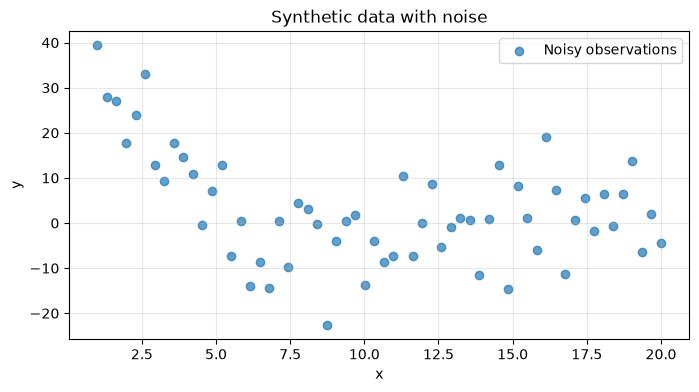

In [34]:
plt.figure(figsize=(8, 4))
plt.scatter(data["x"], data["y"], alpha=0.7, label="Noisy observations")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic data with noise")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Plot Noisy Data vs Noise-Free Truth

The `generate_truth_dataset` function creates a NumPy array with truth data. Copy/paste the plotting code above and plot the truth data next to the synthetic data.

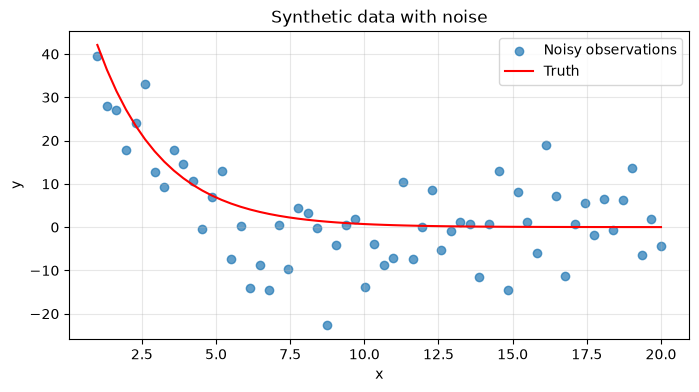

In [35]:
truth_data = gd.generate_truth_dataset(truth)
#TODO: Copy, paste and modify the above code here to see truth and synthetic side by side.  
plt.figure(figsize=(8, 4))
plt.scatter(data["x"], data["y"], alpha=0.7, label="Noisy observations")
plt.plot(truth_data["x"], truth_data["y"], color="red", label="Truth")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic data with noise")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# I recommend you use plot instead of scatter (maybe try both and see which you prefer)


### Explore the Library Functions

Spend some time exploring the functions inside `generate_dataset.py`. Play around with the random seed and see how that changes outputs. Share your exploration with your team and be ready to answer the following questions in class.
- What happens if you set `noise_fraction` really high?
- What happens if you set `noise_fraction` over 1? What might that mean?
- What happens if you set `noise_fraction` to less than 0? What does that error tell you?
- How might you use code like this in your own research?

when noise_fraction is really high: the points became far away with each other
when noise_fraction over 1: the points became more far away from each other, and i cannot say the trend.
when noise_fraction is less than 0: i see error......... that means the noise cannot be less than 0?
i think-- my project is to create a website, whether they can use the mouse to indicate which number of weight/height will be his ideal shape; but, the shape he use mouse to click is not really equal to the ideal shape in his mind, so, there is the noise!

# Advanced Example: Mini Code Review

Now look directly at `generate_dataset.py` and do a mini code review as a group.

The goal is not to rewrite the file. The goal is to understand how the file works and how your tools (`help` and `dir`) reveal what is inside the module.

***TODO:*** As a group, walk through one complete path in the file: 

> inputs -> validation -> model generation -> noise -> returned outputs.

Discussion questions for group share-out:

1. What does `help(generate_dataset)` tell you about expected inputs, defaults, and behavior?
2. What does `dir()` reveal that is defined in the file, and what important things does it not tell you?
3. Where are the guardrails (input validation) in the file, and what student mistakes do they prevent?
4. Which design choice in the file most supports reproducibility, and why?
5. If you had to improve one thing for readability without adding complexity, what would you change?

1. help tell us how to use each function
2. dir() tell us the direction, what names we have in the module
3. input validation is inside generate_dataset, before data generation. It checks that there are at least two points, the noise fraction is not negative, and the model name is valid. These checks prevent invalid inputs
4. the random seed supports reproducibility. With the same seed and settings, we can generate the same data again and compare results.
5. add a short comment explaining the noise calculation. This would make it easier for beginners to understand how noise_fraction controls the amount of noise.

In [36]:
# Mini review helper commands (run and discuss as a group)
import generate_dataset as gd

print("Module-level names from dir():")
print([name for name in dir(gd) if not name.startswith('_')])

print("\nFunction help for generate_dataset:")
help(gd.generate_dataset)

Module-level names from dir():
['MODELS', 'annotations', 'available_models', 'evaluate_truth', 'exponential', 'generate_dataset', 'generate_truth_dataset', 'linear', 'logarithmic', 'np', 'pd', 'quadratic']

Function help for generate_dataset:
Help on function generate_dataset in module generate_dataset:

generate_dataset(model_name: 'str | None' = None, seed: 'int' = 42, n_points: 'int' = 50, noise_fraction: 'float' = 0.1) -> 'tuple[pd.DataFrame, dict[str, object]]'
    Generate a synthetic dataset.

    Parameters
    ----------
    model_name
        Name of the model family to use. If ``None``,
        a model is selected randomly.

    seed
        Random seed used for repeatable dataset generation.

    n_points
        Number of observations to generate.

    noise_fraction
        Standard deviation of the noise as a fraction of the
        model's natural variation.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing columns:

        - ``x``
        - ``

#Put your group Thoughts here and be prepared to discuss as a class. 

If your team is done with this, go ahead and move on to Part 3.